# K Nearest Neighbor Code Goes Here

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load datasets
train_df = pd.read_parquet("../data/train.parquet")
test_df = pd.read_parquet("../data/test.parquet")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns)


# Select text and label columns

TEXT_COLUMN = "text"
LABEL_COLUMN = "label"

X_train_text = train_df[TEXT_COLUMN]
y_train = train_df[LABEL_COLUMN]

X_test_text = test_df[TEXT_COLUMN]
y_test = test_df[LABEL_COLUMN]


# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


# Hyperparameter tuning for k
k_values = range(1, 21)
accuracies = []

print("\nTuning k values...\n")

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="cosine"
    )

    knn.fit(X_train, y_train)

    preds = knn.predict(X_test)

    acc = accuracy_score(y_test, preds)

    accuracies.append(acc)

    print(f"k = {k}  |  Accuracy = {acc:.4f}")


# Select best k
best_k = k_values[np.argmax(accuracies)]

print("\nBest k:", best_k)


# Train final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="cosine"
)

knn.fit(X_train, y_train)


# Final evaluation
y_pred = knn.predict(X_test)

print("\nFinal Results")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Train shape: (25000, 2)
Test shape: (25000, 2)

Columns:
Index(['text', 'label'], dtype='object')

Tuning k values...

k = 1  |  Accuracy = 0.6118
k = 2  |  Accuracy = 0.5972
k = 3  |  Accuracy = 0.6385
k = 4  |  Accuracy = 0.6229
k = 5  |  Accuracy = 0.6487
k = 6  |  Accuracy = 0.6375
k = 7  |  Accuracy = 0.6568
k = 8  |  Accuracy = 0.6464
k = 9  |  Accuracy = 0.6634
k = 10  |  Accuracy = 0.6546
k = 11  |  Accuracy = 0.6704
k = 12  |  Accuracy = 0.6606
k = 13  |  Accuracy = 0.6712
k = 14  |  Accuracy = 0.6656
k = 15  |  Accuracy = 0.6745
k = 16  |  Accuracy = 0.6669
k = 17  |  Accuracy = 0.6790
k = 18  |  Accuracy = 0.6723
k = 19  |  Accuracy = 0.6828
k = 20  |  Accuracy = 0.6776

Best k: 19

Final Results

Accuracy:
0.6828

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.78      0.71     12500
           1       0.73      0.58      0.65     12500

    accuracy                           0.68     25000
   macro avg       0.69

In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.6828
Confusion Matrix:
 [[9807 2693]
 [5237 7263]]
Precision: 0.7295098433105665
Recall: 0.58104
F1 Score: 0.6468649804061275


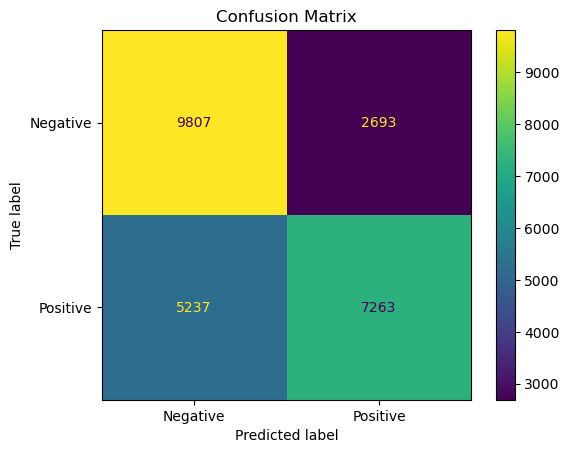

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()